<a href="https://colab.research.google.com/github/LuanLuna12705/test/blob/main/Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Xử lý dữ liệu

In [ ]:
import pandas as pd
# 1. Đọc và lấy các cột cần thiết ngay từ đầu
df_data = pd.read_csv('data.txt', sep=r'\s+', comment='%', header=None,
                      names=['Station_ID', 'Series', 'Date_Decimal', 'Temp', 'Uncertainty', 'Obs', 'Time_Obs'])
df_sites = pd.read_csv('site_summary.txt', sep=r'\s+', comment='%', header=None,
                       names=['Station_ID', 'Latitude', 'Longitude', 'Elevation'])[['Station_ID', 'Latitude', 'Longitude']]
df_stats = pd.read_csv('data_characterization.txt', sep=r'\s+', comment='%', header=None,
                       usecols=[0, 10, 11], names=['Station_ID', 'Max_Value', 'Min_Value'])
# 2. Hàm định dạng ngày
def format_date(d):
    return f"{max(1, min(12, int((d % 1) * 12 + 1.5))):02d}/{int(d)}"
# 3. Xử lý tập trung: Lọc -> Merge -> Định dạng
final_table = df_data[(df_data['Date_Decimal'] >= 2018) & (df_data['Date_Decimal'] < 2021)].copy()
final_table = final_table.merge(df_sites, on='Station_ID', how='left').merge(df_stats, on='Station_ID', how='left')
final_table['Date_Formatted'] = final_table['Date_Decimal'].apply(format_date)
# 4. Chọn cột cuối cùng và Lưu file
cols = ['Station_ID', 'Date_Formatted', 'Temp', 'Min_Value', 'Max_Value', 'Latitude', 'Longitude']
final_table[cols].to_csv('du_lieu_tong_hop_2018_2021.csv', index=False, encoding='utf-8-sig')

print("BẢNG DỮ LIỆU TỔNG HỢP:\n", final_table[cols].head(10).to_string(index=False))
print("\nĐã lưu file thành công!")

BẢNG DỮ LIỆU TỔNG HỢP:
  Station_ID Date_Formatted  Temp  Min_Value  Max_Value  Latitude  Longitude
      47499        02/2018  -7.2    -22.088      -56.6     -83.1      174.2
      47499        03/2018 -17.9    -22.088      -56.6     -83.1      174.2
      47499        03/2018 -21.1    -22.088      -56.6     -83.1      174.2
      47499        05/2018 -24.8    -22.088      -56.6     -83.1      174.2
      47499        06/2018 -30.6    -22.088      -56.6     -83.1      174.2
      47499        06/2018 -28.2    -22.088      -56.6     -83.1      174.2
      47499        08/2018 -32.2    -22.088      -56.6     -83.1      174.2
      47499        09/2018 -36.7    -22.088      -56.6     -83.1      174.2
      47499        09/2018 -32.1    -22.088      -56.6     -83.1      174.2
      47499        11/2018 -18.3    -22.088      -56.6     -83.1      174.2

Đã lưu file thành công!


Figure 1 : *THUẬT TOÁN GREEDY*

Tổng trạm: 2615 | Chọn: 78 trạm (3%) dựa trên Biên độ nhiệt


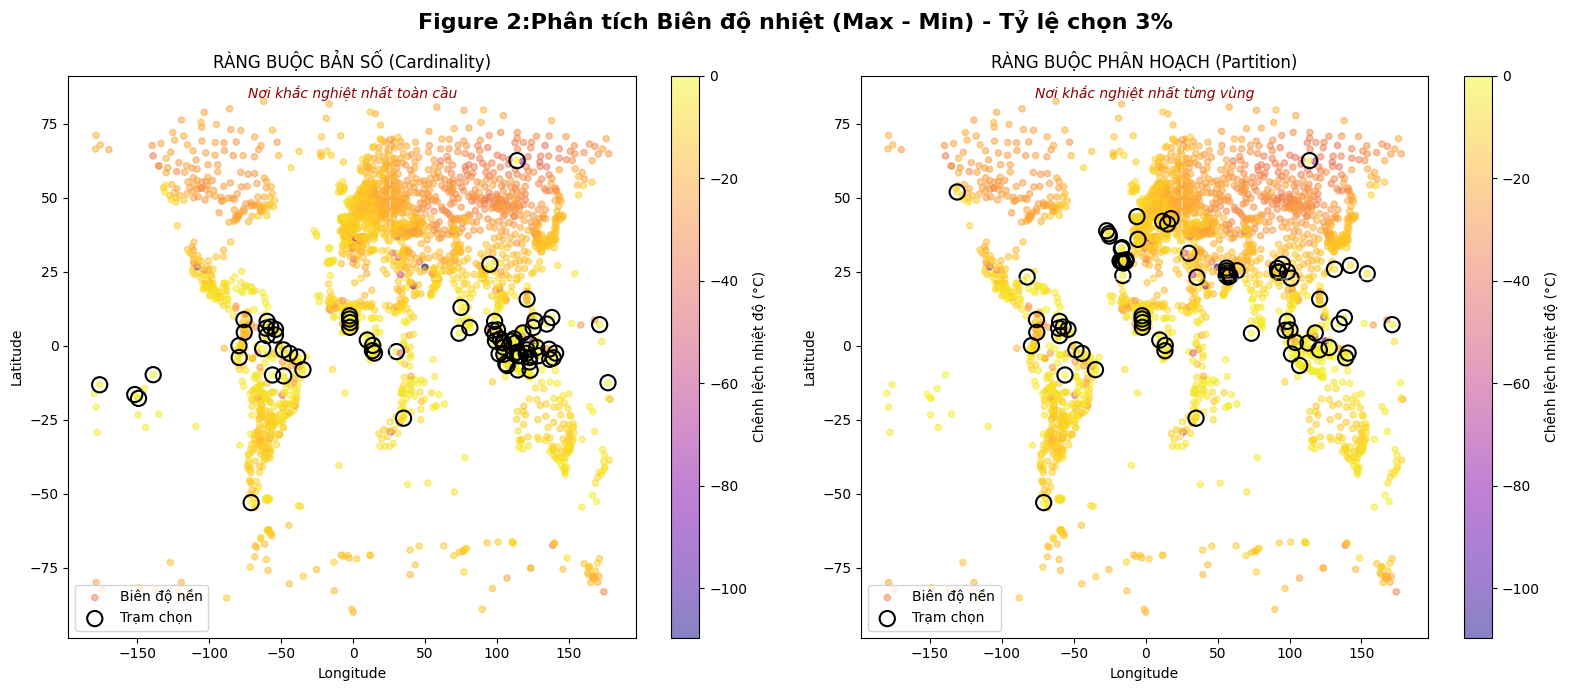

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- BƯỚC 1: XỬ LÝ DỮ LIỆU ---
df = pd.read_csv('du_lieu_tong_hop_2018_2021.csv').groupby(['Station_ID', 'Latitude', 'Longitude']).agg({'Max_Value': 'max', 'Min_Value': 'min'}).reset_index()
df['Temp_Range'] = df['Max_Value'] - df['Min_Value']

x, y, values = df['Longitude'].values, df['Latitude'].values, df['Temp_Range'].values
k = max(1, int(len(df) * 0.03))

print(f"Tổng trạm: {len(df)} | Chọn: {k} trạm (3%) dựa trên Biên độ nhiệt")

# --- BƯỚC 2: THUẬT TOÁN GREEDY ---
# 1. Bản số (Cardinality): Top k trạm toàn cục
idx_cardinality = np.argsort(values)[::-1][:k]

# 2. Phân hoạch (Partition): Top k/4 trạm mỗi vùng
avg_x, avg_y = np.mean(x), np.mean(y)
idx_partition = []
limit = k // 4 + 1

# Tạo 4 mặt nạ (masks) cho 4 góc phần tư
masks = [
    (x >= avg_x) & (y >= avg_y), (x < avg_x) & (y >= avg_y),
    (x < avg_x) & (y < avg_y), (x >= avg_x) & (y < avg_y)
]

for mask in masks:
    idx_in_zone = np.where(mask)[0]
    # Sắp xếp các trạm trong vùng theo biên độ giảm dần và lấy top
    top_in_zone = idx_in_zone[np.argsort(values[idx_in_zone])[::-1][:limit]]
    idx_partition.extend(top_in_zone)

idx_partition = idx_partition[:k]

# --- BƯỚC 3: VẼ ĐỒ THỊ ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def plot_map(ax, selected_idx, title, subtitle):
    sc = ax.scatter(x, y, c=values, cmap='plasma', s=20, alpha=0.5, label='Biên độ nền')
    ax.scatter(x[selected_idx], y[selected_idx], s=120, facecolors='none', edgecolors='k', lw=1.5, label='Trạm chọn')

    ax.axvline(avg_x, color='w', ls='--', alpha=0.4)
    ax.axhline(avg_y, color='w', ls='--', alpha=0.4)

    ax.set(title=title, xlabel="Longitude", ylabel="Latitude")
    ax.text(0.5, 0.96, subtitle, transform=ax.transAxes, ha='center', fontsize=10, fontstyle='italic', color='darkred')
    plt.colorbar(sc, ax=ax, label="Chênh lệch nhiệt độ (°C)")
    ax.legend(loc='lower left')

plot_map(axes[0], idx_cardinality, "RÀNG BUỘC BẢN SỐ (Cardinality)", "Nơi khắc nghiệt nhất toàn cầu")
plot_map(axes[1], idx_partition, "RÀNG BUỘC PHÂN HOẠCH (Partition)", "Nơi khắc nghiệt nhất từng vùng")

fig.suptitle(f"Figure 2:Phân tích Biên độ nhiệt (Max - Min) - Tỷ lệ chọn 3%", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Figure 2: *3 trạm có phương sai lớn nhất*

Top 3 Station IDs có biến động cao nhất: [51854 51799 51839]


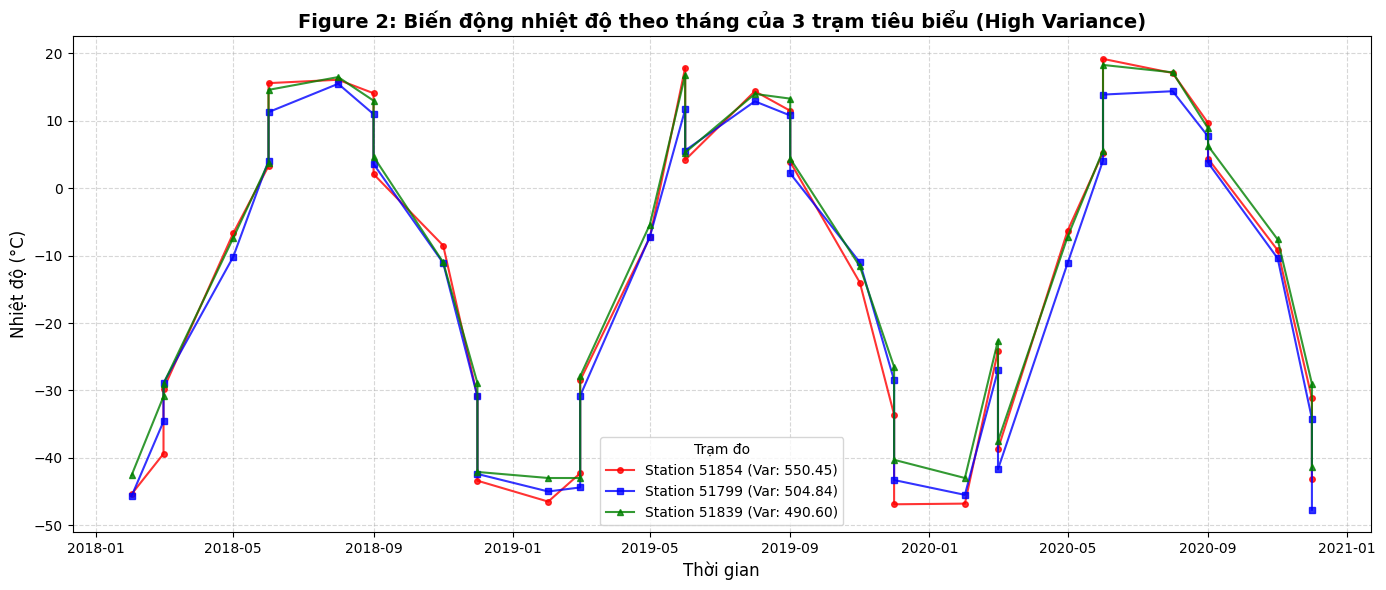

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. ĐỌC DỮ LIỆU
df = pd.read_csv('du_lieu_tong_hop_2018_2021.csv')

# Chuyển đổi cột Date_Formatted sang dạng datetime để vẽ trục thời gian cho đúng
df['Date'] = pd.to_datetime(df['Date_Formatted'], format='%m/%Y')

# 2. TÌM 3 TRẠM CÓ BIẾN ĐỘNG (VARIANCE) CAO NHẤT
station_stats = df.groupby('Station_ID')['Temp'].var().reset_index()
station_stats.columns = ['Station_ID', 'Variance']

# Lấy Top 3 trạm có phương sai lớn nhất
top_3_stations = station_stats.sort_values(by='Variance', ascending=False).head(3)
top_3_ids = top_3_stations['Station_ID'].values

print("Top 3 Station IDs có biến động cao nhất:", top_3_ids)

# 3. VẼ BIỂU ĐỒ CHUỖI THỜI GIAN (TIME SERIES)
plt.figure(figsize=(14, 6))

colors = ['red', 'blue', 'green']
markers = ['o', 's', '^']

for i, station_id in enumerate(top_3_ids):
    # Lấy dữ liệu của trạm này
    station_data = df[df['Station_ID'] == station_id].sort_values(by='Date')

    # Vẽ đường
    plt.plot(station_data['Date'], station_data['Temp'],
             label=f'Station {int(station_id)} (Var: {top_3_stations.iloc[i]["Variance"]:.2f})',
             color=colors[i], marker=markers[i], markersize=4, linewidth=1.5, alpha=0.8)

# Trang trí biểu đồ
plt.title('Figure 2: Biến động nhiệt độ theo tháng của 3 trạm tiêu biểu (High Variance)', fontsize=14, fontweight='bold')
plt.ylabel('Nhiệt độ (°C)', fontsize=12)
plt.xlabel('Thời gian', fontsize=12)
plt.legend(title='Trạm đo', loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Figure 3: Hiệu năng cực đại hóa Entropy

Đang xử lý dữ liệu...
Đang chạy thuật toán (chỉ tốn vài giây)...


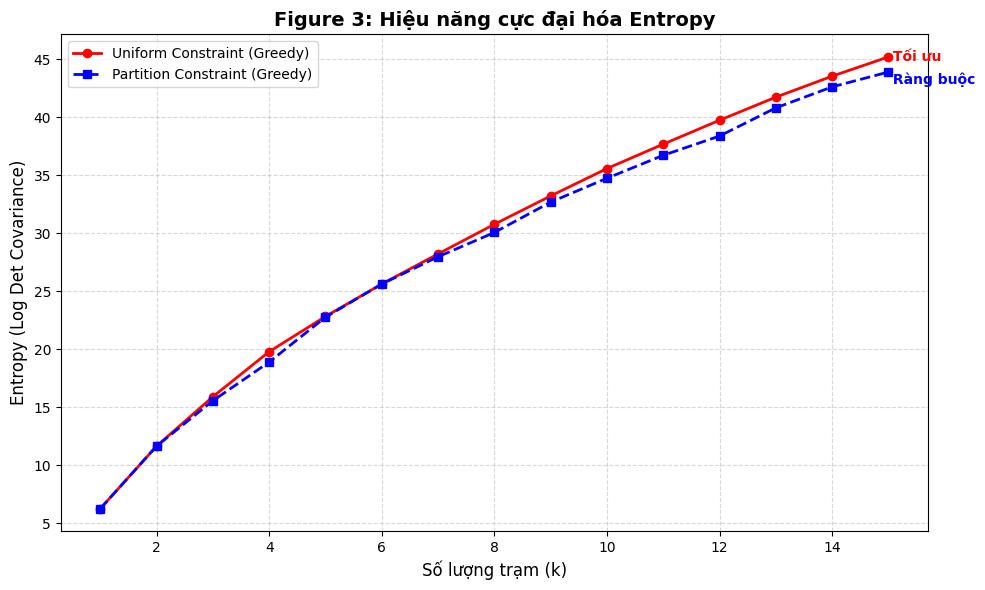

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU & MA TRẬN HIỆP PHƯƠNG SAI ---
print("Đang xử lý dữ liệu...")
df = pd.read_csv('du_lieu_tong_hop_2018_2021.csv')

# 1. Tạo pivot table TRƯỚC
pivot_df = df.pivot_table(index='Date_Formatted', columns='Station_ID', values='Temp')

# 2. Xử lý NaN (Sửa lại đúng thành len(pivot_df))
pivot_df = pivot_df.dropna(axis=1, thresh=int(len(pivot_df)*0.8)).ffill().bfill()

# 3. Lấy ma trận numpy và tọa độ
cov_matrix = pivot_df.cov().values
n_total = len(cov_matrix)

coords = df.drop_duplicates('Station_ID').set_index('Station_ID').loc[pivot_df.columns]
x, y = coords['Longitude'].values, coords['Latitude'].values

avg_x, avg_y = x.mean(), y.mean()
# Chia 4 vùng bằng Numpy masks
masks = [(x >= avg_x) & (y >= avg_y), (x < avg_x) & (y >= avg_y),
         (x < avg_x) & (y < avg_y), (x >= avg_x) & (y < avg_y)]

# --- BƯỚC 2 & 3: HÀM MỤC TIÊU & THUẬT TOÁN GREEDY ---
def calc_entropy(idx):
    """Tính Entropy log det(Σ_S) dựa trên danh sách index truyền vào"""
    if not idx: return 0
    sign, logdet = np.linalg.slogdet(cov_matrix[np.ix_(idx, idx)])
    return logdet if sign > 0 else -np.inf

def greedy_uniform(k):
    """Chọn k trạm làm tăng Entropy nhiều nhất"""
    S = []
    for _ in range(k):
        best_i = max((i for i in range(n_total) if i not in S), key=lambda i: calc_entropy(S + [i]))
        S.append(best_i)
    return calc_entropy(S)

def greedy_partition(k):
    """Chia 4 vùng, mỗi vùng chọn tối đa k/4 trạm"""
    S = []
    limit = int(np.ceil(k / 4))

    for mask in masks:
        zone_idx = np.where(mask)[0].tolist()
        for _ in range(limit):
            if len(S) >= k or not zone_idx: break
            best_i = max(zone_idx, key=lambda i: calc_entropy(S + [i]))
            S.append(best_i)
            zone_idx.remove(best_i)

    return calc_entropy(S)

# --- BƯỚC 4: CHẠY MÔ PHỎNG VÀ VẼ HÌNH ---
k_values = list(range(1, 16))

y_uniform = [greedy_uniform(k) for k in k_values]
y_partition = [greedy_partition(k) for k in k_values]

# Vẽ đồ thị
plt.figure(figsize=(10, 6))
plt.plot(k_values, y_uniform, 'r-o', lw=2, label='Uniform Constraint (Greedy)')
plt.plot(k_values, y_partition, 'b--s', lw=2, label='Partition Constraint (Greedy)')

plt.title('Figure 3: Hiệu năng cực đại hóa Entropy', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng trạm (k)', fontsize=12)
plt.ylabel('Entropy (Log Det Covariance)', fontsize=12)
plt.legend()
plt.grid(ls='--', alpha=0.5)

plt.text(k_values[-1], y_uniform[-1], ' Tối ưu', color='red', va='center', fontweight='bold')
plt.text(k_values[-1], y_partition[-1], ' Ràng buộc', color='blue', va='top', fontweight='bold')

plt.tight_layout()
plt.show()

Figure 4:Trực quan hóa Ma trận Hiệp phương sai $\Sigma$

<>:12: SyntaxWarning: invalid escape sequence '\S'
<>:12: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_202/1552737200.py:12: SyntaxWarning: invalid escape sequence '\S'
  plt.title('Figure 4:Trực quan hóa Ma trận Hiệp phương sai $\Sigma$', fontsize=14, pad=15)


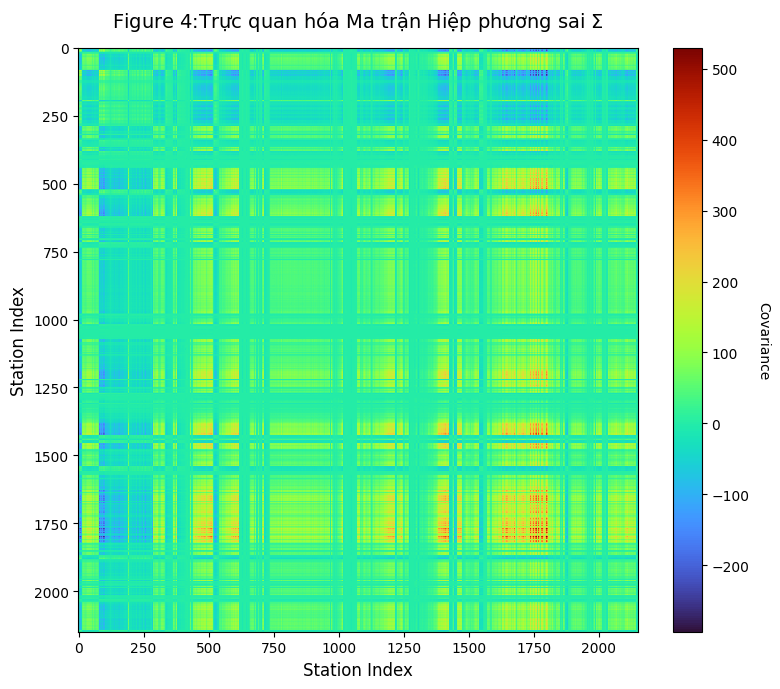

In [ ]:
import matplotlib.pyplot as plt

matrix_data = cov_matrix
plt.figure(figsize=(8, 7))
im = plt.imshow(matrix_data, cmap='turbo', aspect='auto', interpolation='nearest')


cbar = plt.colorbar(im)
cbar.set_label('Covariance', rotation=270, labelpad=15)

# Căn chỉnh tiêu đề và trục
plt.title('Figure 4:Trực quan hóa Ma trận Hiệp phương sai $\Sigma$', fontsize=14, pad=15)
plt.xlabel('Station Index', fontsize=12)
plt.ylabel('Station Index', fontsize=12)


plt.tight_layout()
plt.show()